<a href="https://colab.research.google.com/github/Talat30/License-Plate-Detection/blob/main/obj31_skilling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sujaymann/car-number-plate-dataset-yolo-format")

print("Path to dataset files:", path)

100%|██████████| 203M/203M [00:08<00:00, 26.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sujaymann/car-number-plate-dataset-yolo-format/versions/3


In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip -d /content/dataset

In [ ]:
import os

dataset_path = "/content/dataset"
print("Top-level files/folders:", os.listdir(dataset_path))

# Check train images
train_images = os.listdir(os.path.join(dataset_path, "/content/dataset/License-Plate-Data/train/images"))
print("First 5 train images:", train_images[:5])

# Check train labels
train_labels = os.listdir(os.path.join(dataset_path, "/content/dataset/License-Plate-Data/train/labels"))
print("First 5 label files:", train_labels[:5])

Top-level files/folders: ['License-Plate-Data']
First 5 train images: ['Cars14.png', 'Cars278.png', 'Cars217.png', 'Cars105.png', 'Cars402.png']
First 5 label files: ['Cars97.txt', 'Cars411.txt', 'Cars90.txt', 'Cars134.txt', 'Cars107.txt']


In [ ]:
data_yaml = """
path: /content/dataset/License-Plate-Data
train: train/images
val: test/images

nc: 1
names: ['license_plate']
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created!")

data.yaml created!


In [ ]:
import warnings
warnings.filterwarnings('ignore')
!pip install ultralytics
from ultralytics import YOLO


# YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Fast training config
results = model.train(
    data="data.yaml",
    epochs=2,       # very few epochs
    imgsz=416,      # smaller images = faster
    batch=8,        # smaller batch for quick run
    name="yolov8_license_plate_quickest"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=

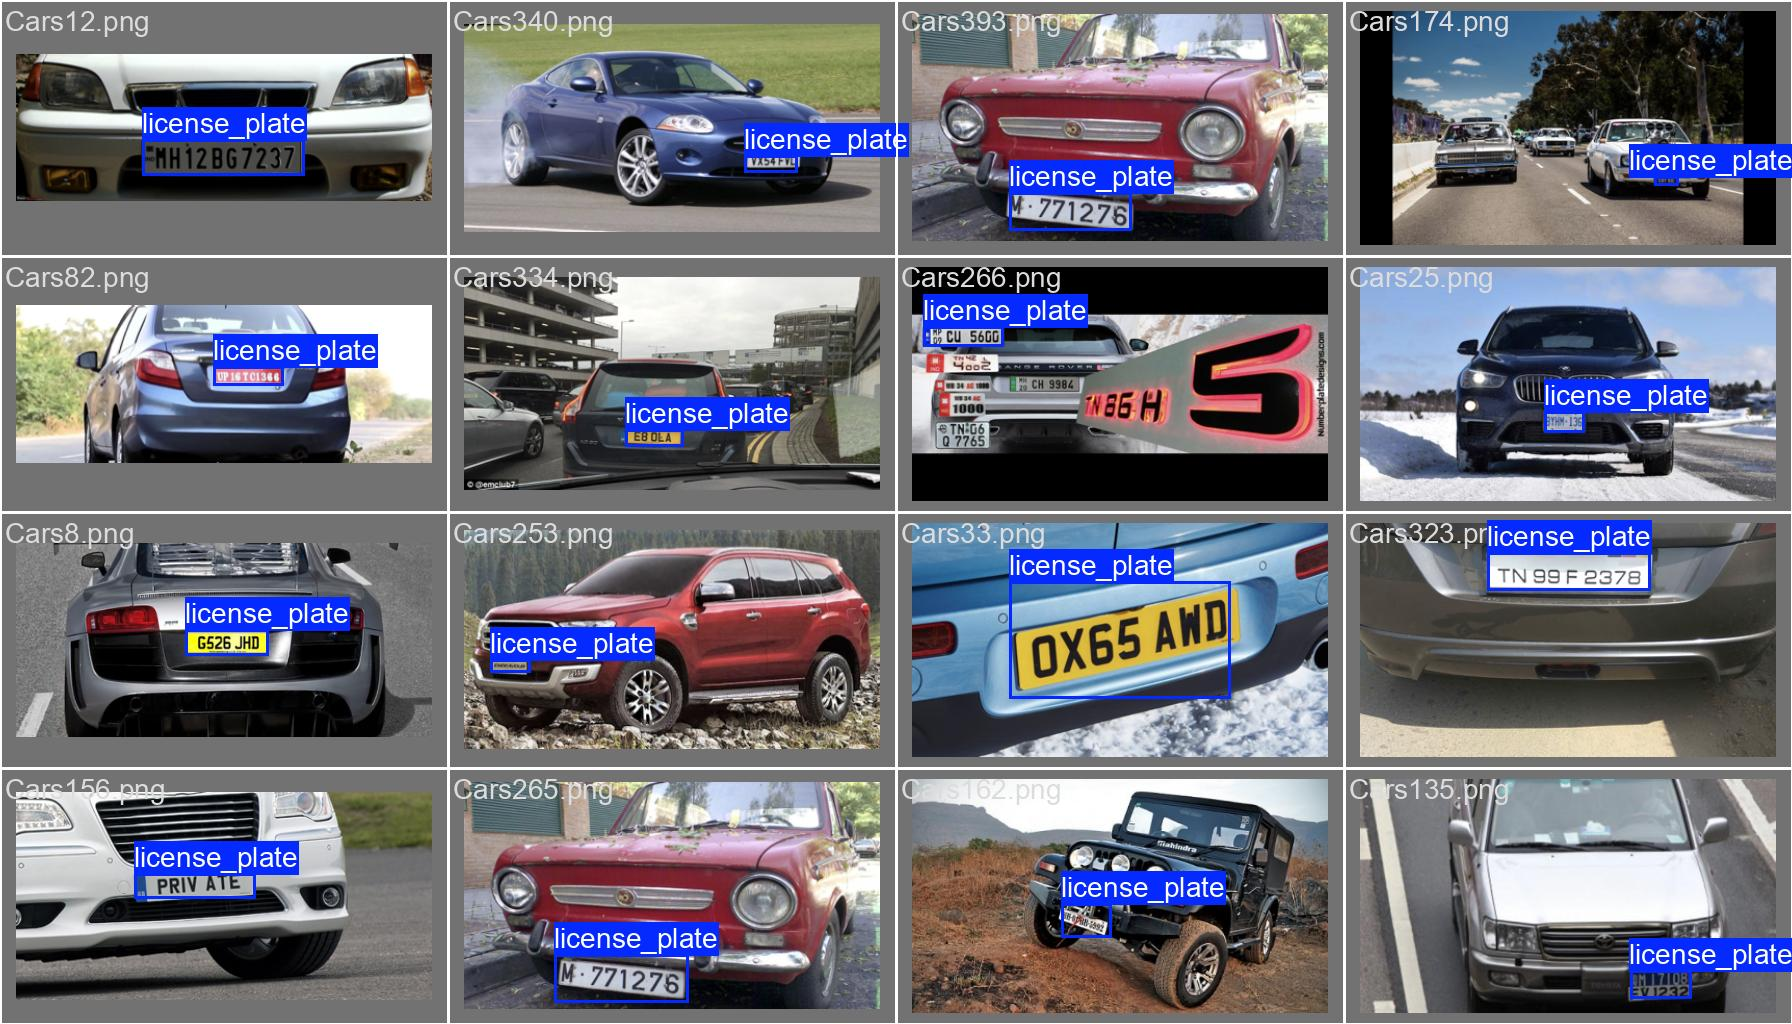

In [ ]:
from IPython.display import Image, display

display(Image(filename="//content/runs/detect/yolov8_license_plate_quickest/val_batch0_labels.jpg"))